# Diffraction

Being able to visualize and manipulate concepts in real time is a very powerful tool for gaining intuition about a concept or system you're working with. Throughout this assignment, we will use Python to create interactive plots for just this purpose.

In the previous laboratory, we studied the behavior of waves under spatial boundary conditions and observed that confinement leads to structured interference patterns. In this experiment, we extend these ideas by studying diffraction as a consequence of spatial confinement and interference. We begin with light passing through a finite aperture (single-slit diffraction), where restricting a wave in space produces a continuous angular distribution. We then consider interference from two localized sources (double-slit diffraction), where discrete angular fringes emerge from phase matching. Finally, we examine the limiting case of many regularly spaced scattering centers: a crystalline lattice.

At each stage, the same physical principle applies: waves originating from different points accumulate relative phase, and only certain angular configurations satisfy the condition for constructive interference. Increasing geometric structure sharpens these interference conditions, progressing from broad diffraction envelopes (single slit), to discrete fringes (double slit), and ultimately to sharp diffraction peaks produced by periodic atomic planes.

---

**Chemistry Learning Objectives:**
- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints, progressing from single-slit and double-slit systems to periodic crystal lattices, and derive Bragg's law from phase matching.
- C2.2: Use powder XRD data to determine lattice spacings and relate extracted structural parameters to underlying crystal structures.
- C2.3: Interpret diffraction features in terms of spatial confinement, periodicity, and finite domain size, connecting angular structure to real-space geometry.

**Programming Learning Objectives:**
- P2.1: Write simple Python functions to model single-slit, double-slit, and lattice-based angular interference, generating synthetic diffraction patterns for multiple parameter choices.
- P2.2: Implement basic data-analysis workflows (peak identification and regression) using structured, reusable code rather than isolated cells.
- P2.3: Construct small modular programs that separate physical models from visualization and analysis, reinforcing the connection between mathematical equations and computational implementation.

---

**Table of Contents**
- [Part 1 - Single-Slit Diffraction](#Part-1---Single-Slit-Diffraction) `40 points`
- [Part 2 - Phase Differences and Angular Interference](#Part-2---Phase-Differences-and-Angular-Interference) `40 points`
- [Part 3 - The Crystal Lattice and Mirror Planes](#Part-3---The-Crystal-Lattice-and-Mirror-Planes) `50 points`
- [Part 4 - Powder Diffraction and Interpreting XRD Spectra](#Part-4---Powder-Diffraction-and-Interpreting-XRD-Spectra) `40 points`
- [Reflection](#Reflection) `10 points`

`Total: 180 points`

<br></br>

## Part 1 - Single-Slit Diffraction

In the previous laboratory, standing waves arose because a finite spatial domain imposed boundary conditions on a wave. Only certain phase relationships were compatible with those boundaries, leading to discrete allowed modes.

Diffraction from a single slit is governed by the same idea. Instead of confinement along a string, we now have confinement in a transverse spatial direction. Light passing through a narrow aperture spreads out, and the angular distribution of intensity is determined by interference between contributions from different points across the slit.

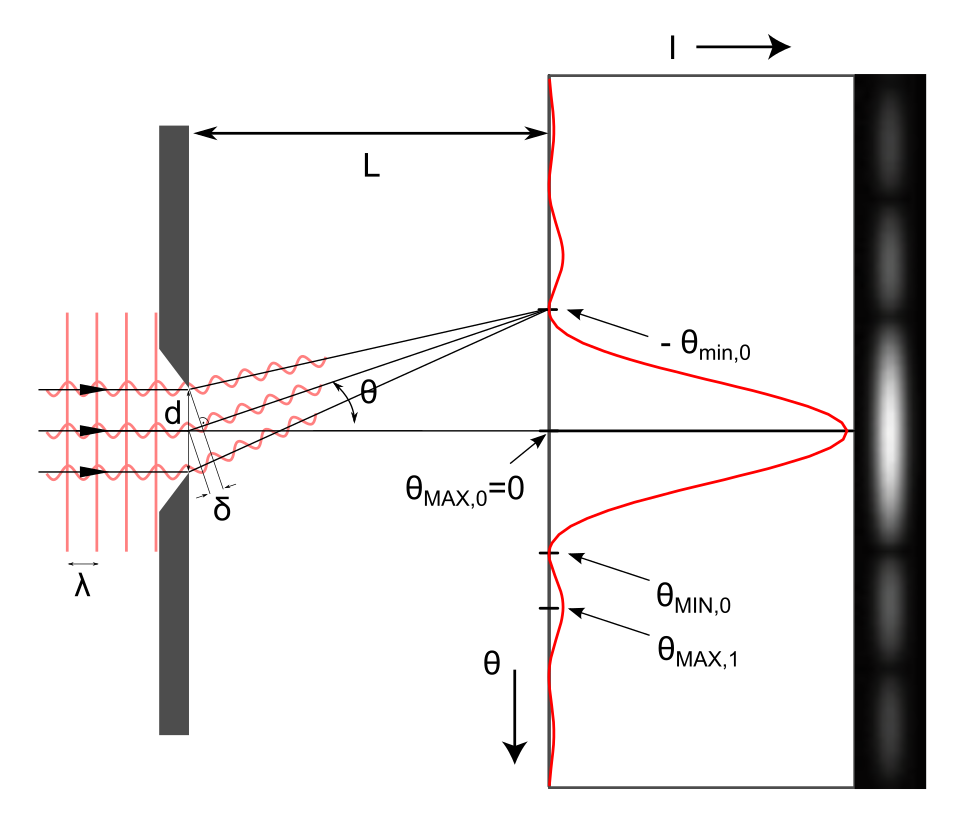

(image credit: https://commons.wikimedia.org/wiki/File:Single_Slit_Diffraction.svg)

Unlike the crystal lattice case (which we will study later), a single slit does not impose periodic structure. Instead, it imposes a finite spatial extent. This produces a continuous diffraction envelope whose shape reflects the width of the aperture.

Consider a slit of width $a$, illuminated by monochromatic light of wavelength $\lambda$. In the far-field (Fraunhofer) limit, the intensity as a function of observation angle $\theta$ is
$$
I (\theta) \propto \left( \frac{\sin \beta}{\beta} \right)^2, \quad \beta = \frac{\pi a}{\lambda} \sin \theta
$$
This result can be derived by summing (integrating) the phase contributions from each point across the slit. The key features are:

 - The pattern has a central maximum at $\theta = 0$.
 - Intensity minima occur when
    $$
    a \sin \theta = m \lambda, \quad m = \pm 1, \pm 2, \dots
    $$
 - Increasing the slit width $a$ narrows the angular distribution.
 - Decreasing the wavelength \(\lambda\) also narrows the angular distribution.

Conceptually, this is the diffraction analogue of standing waves: restricting a wave in space necessarily spreads it in angle. This tradeoff between spatial confinement and angular (or momentum) spread will reappear later when we discuss crystals and peak broadening.

In this section, you will implement this model computationally and explore how the diffraction pattern depends on slit width and wavelength.

### Coding Activity 1
`30 points`

- P2.1: Write simple Python functions to model single-slit, double-slit, and lattice-based angular interference
- P2.3: Construct small modular programs that separate physical models from visualization and analysis

Write simple Python functions to evaluate the single-slit diffraction intensity and visualize how spatial confinement controls angular structure. You will use these functions repeatedly later, so focus on clarity and reusability.

#### Part A - Implement the Diffraction Model

Write a function that computes
$$
\beta (\theta; a, \lambda) = \frac{\pi a}{\lambda} \sin \theta
$$
and a second function that evaluates
$$
I(\theta) = \left( \frac{\sin \beta}{\beta} \right)^2.
$$

Your function should:
 - accept \(\theta\) in radians (scalar or NumPy array),
 - take slit width \(a\) and wavelength \(\lambda\) as parameters,
 - return a dimensionless intensity.

Handle the removable singularity at \(\beta = 0\) so that the intensity remains finite at \(\theta = 0\)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Part A: Single-slit model
# ------------------------------------------------------------

def beta(theta, a, wavelength):
    """
    Compute

        β(θ; a, λ) = (π a / λ) sin(θ)

    Parameters
    ----------
    theta : array_like
        Observation angle in radians.
    a : float
        Slit width.
    wavelength : float
        Wavelength (same units as a).

    Returns
    -------
    beta : array_like
        Dimensionless phase parameter.
    """
    beta = np.pi * a / wavelength * np.sin(theta)
    return beta

def single_slit_intensity(theta, a, wavelength):
    """
    Single-slit diffraction intensity:

        I(θ) = (sin β / β)^2

    with β defined above. The removable singularity at β = 0
    should be handled so that I(0) = 1.

    Parameters
    ----------
    theta : array_like
        Observation angle in radians.
    a : float
        Slit width.
    wavelength : float
        Wavelength.

    Returns
    -------
    I : array_like
        Dimensionless intensity.
    """
    beta_val = beta(theta,a,wavelength)
    I = (np.sin(beta_val) / beta_val) ** 2
    return I


#### Part B - Visualize the Diffraction Pattern

1. Create an angular grid over a small range (for example $ \theta \in [-\pi / 6, \pi / 6 ]$).
2. Plot $I(\theta)$ for a reasonable choice of \(a\) and \(\lambda\). Plots should have a main title as well as axis titles. Use formatted strings such as `r$\lambda$` for math expressions.
3. Vary \(a\) while holding \(\lambda\) fixed. Generate new plots and observe how the pattern changes.
4. Vary \(\lambda\) while holding \(a\) fixed. Generate new plots and observe how the pattern changes.

Text(0.5, 1.0, 'Intensity vs angle')

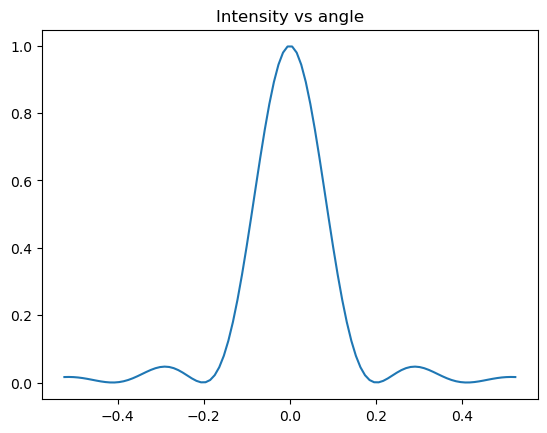

In [20]:

# ------------------------------------------------------------
# Part B: Visualization template
# ------------------------------------------------------------

# Angular grid (small-angle region)
theta = np.linspace(-np.pi/6, np.pi/6, 100)

# Example physical parameters (students should explore)
a = 0.5
wavelength = 0.1

# Evaluate model
I = single_slit_intensity(theta, a, wavelength)

# Plot
plt.plot(theta,I)
plt.title("Intensity vs angle")


#### Part C - Locate Diffraction Minima

Using your intensity function:

Numerically identify the first few angles at which the intensity goes to (or near) zero.

Compare these values to the theoretical condition
$$
a \sin \theta =m \lambda.
$$
You do not need a sophisticated root-finding routine; approximate locations are sufficient.

In [ ]:

# identify zeros
list_small_vals = []
for i,I_val in enumerate(I):
    if I_val < 0.01:
        list_small_vals.append(theta[i])
print(list_small_vals)
print("goes to zero around +/ 0.5 radians")

# students would need to understand the difference between list indices and content
# try doing this in a dumber way... see if I could do it only with elementary python
print("sin(theta)")
print(np.sin(list_small_vals))
print("n * lambda")
print(1 * wavelength)

# yeah, they're the same. don't know if students could do this though, nontrivial.
# trivial for someone who knows python... nontrivial for someone doing it for the first few times


### Question 1
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.3: Interpret diffraction features in terms of spatial confinement

Explain why narrowing the slit causes the diffraction pattern to spread out in angle. In what sense is the slit width $a$ playing the same conceptual role as the length $L$ in a standing-wave problem?

---


narrowing the slit causes spatial confinement for the xy component of the wave... this results in greater uncertainty in the xy momentum which causes the wave to spread out more, because of the uncertainty principle. The length L in the standing wave problem corresponds to this because in both cases the length of confinement is changing the pattern of constructive interference we observe.

<br></br>

## Part 2 - Phase Differences and Angular Interference

### 2.1 The Double Slit Experiment
In Section 2, diffraction arose from continuous spatial confinement: restricting a wave to pass through a finite aperture produced a broadened angular distribution. We now introduce a second slit. This produces a qualitatively new feature: discrete angular fringes. These fringes arise because waves traveling along different paths accumulate different phases.

Consider two identical slits separated by a distance $d$. Light emerging from each slit travels a different distance to reach a point on the screen at angle $\theta$. The resulting path difference is

$$
\Delta(\theta) = d \sin \theta.
$$

A path difference $\Delta$ corresponds to a phase difference

$$
\Delta \phi(\theta)
=
\frac{2\pi}{\lambda}\,\Delta(\theta)
=
\frac{2\pi}{\lambda} d \sin \theta.
$$

The electric fields from the two slits combine linearly, but the observed brightness depends on intensity, which is proportional to the square of the total amplitude:

$$
I \propto A^2.
$$

As a result, the relative phase between the two contributions determines whether they interfere constructively or destructively.

Constructive interference occurs when the two waves are in phase:

$$
\Delta \phi = 2\pi n,
$$

which gives

$$
d \sin \theta = n \lambda.
$$

Destructive interference occurs when the waves are out of phase by $$\pi$$:

$$
\Delta \phi = (2n+1)\pi,
$$

leading to

$$
d \sin \theta = \left(n + \frac12\right)\lambda.
$$

Thus the angular fringe pattern is a direct consequence of phase matching between the two paths.

Run the interactive cell below to explore how slit separation and wavelength control the angular interference pattern.

In [21]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from helper import interactive_double_slit_plot
interactive_double_slit_plot()

interactive(children=(FloatSlider(value=0.0, description='theta', max=90.0, min=-90.0), Output()), _dom_classe…

### 2.2 Periodicity

The double slit represents the simplest configuration in which discrete angular structure emerges from interference. What happens if we continue this process and increase the number of equally spaced scatterers?

As more sources are added,

- the maxima become sharper,  
- off-peak angles are increasingly suppressed,  
- and the interference pattern approaches a set of narrow angular peaks.

At this point, we will perform a demonstration using many equally spaced slits to illustrate how increasing the number of sources transforms broad interference fringes into sharp angular maxima.

As you observe the pattern, pay attention to the following:

- how the main peaks become narrower as more slits are added,  
- how intensity between peaks decreases,  
- and how only specific angles remain strongly allowed.

This demonstration provides a macroscopic analogue of what occurs in a crystal lattice.

In [22]:
from helper import interactive_diffraction_plot
interactive_diffraction_plot()

interactive(children=(FloatSlider(value=0.0, description='theta', max=70.0, min=-70.0), Output()), _dom_classe…

### 2.3 Two Scatterers in a Crystal

In the limit of a very large number of regularly spaced scatterers, the system becomes effectively periodic. At that point, only specific angles satisfy the phase-matching condition, and diffraction consists of sharp reflections rather than broad fringes.

A crystal lattice is precisely such a system: an enormous periodic array of atoms. X-ray diffraction is therefore the many-slit limit of the double-slit experiment.

In the previous demonstration, you observed how a large number of equally spaced mirrors produces sharp angular maxima, while suppressing intensity at most other angles. This behavior arose purely from periodic geometry and phase matching.

We now zoom in to atomic length scales.

A crystal lattice may be viewed as an array of localized scattering centers (atoms). Although real crystals contain an enormous number of atoms, the essential physics can already be seen by considering the simplest crystalline analogue of the double slit: diffraction from two atoms separated by a fixed distance.

Run the interactive below, which displays the diffraction pattern produced by two points on a crystal lattice.

In [ ]:
from helper import interactive_reflection_plot
interactive_reflection_plot()

interactive(children=(FloatSlider(value=0.0, description='x2', max=1.0, min=-1.0, step=0.01), FloatSlider(valu…

Although the physical interpretation is different, the mathematics is identical to the double-slit case. The separation $d$ now represents an interatomic spacing rather than a macroscopic slit separation, but the interference condition is unchanged.

The path difference between rays scattered from the two atoms is

$$
\Delta (\theta) = 2d \sin \theta 
$$

which produces a phase difference
$$
\Delta \phi(\theta) = \frac{4 \pi}{\lambda} d \sin \theta.
$$

Constructive interference therefore occurs when

$$
\Delta \phi = 2 \pi n,
$$

or equivalently,

$$
2d \sin \theta = n \lambda.
$$

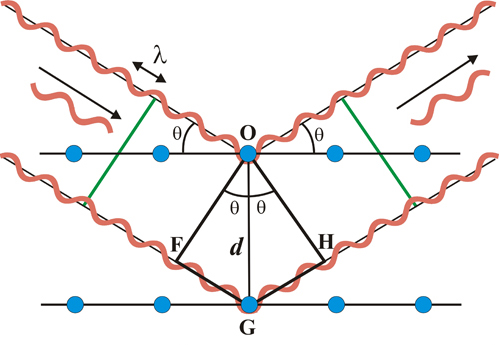

(image source: https://www.xtal.iqf.csic.es/Cristalografia/parte_05_5-en.html)

This demonstrates a key idea: diffraction from atoms follows exactly the same wave-interference rules as diffraction from slits. The difference lies only in scale. In both cases, discrete angular structure arises from phase matching between waves traveling along different paths.

Here, the sources are atoms rather than apertures. Nevertheless, the observed pattern is governed by the same geometric and phase relationships.

### Coding Activity 2
`30 points`

- P2.1: Write simple Python functions to model single-slit, double-slit, and lattice-based angular interference
- P2.3: Construct small modular programs that separate physical models from visualization and analysis

In this challenge, you will construct a minimal two-scatterer interference model and verify that discrete angular maxima arise directly from phase matching. This model will serve as a bridge between the optical double-slit experiment and atomic-scale diffraction.

Your goal is not to reproduce experimental data, but to translate the phase-difference equations derived in this section into a simple computational model.

---

#### Part A - Path Difference and Phase Difference

Write a function that computes the path difference

$$
\Delta(\theta; d) = d \sin \theta .
$$

Then write a second function that converts this into a phase difference:

$$
\Delta\phi(\theta; d,\lambda) = \frac{2\pi}{\lambda} d \sin \theta .
$$

Your functions should accept $\theta$ in radians and work for both scalar and NumPy array inputs.

---

**Expected Deliverables:**

1. A function computing $\Delta(\theta;d)$.
2. A function computing $\Delta\phi(\theta;d,\lambda)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Part A: Path difference and phase difference
# ------------------------------------------------------------

def path_difference(theta, d):
    """
    Compute the path difference for two scatterers separated by distance d:

        Δ(θ; d) = d sin(θ)

    Parameters
    ----------
    theta : array_like
        Observation angle in radians.
    d : float
        Separation between scatterers (same units as wavelength).

    Returns
    -------
    Δ : array_like
        Path difference.
    """
    # TODO: implement
    pass


def phase_difference(theta, d, wavelength):
    """
    Convert path difference into a phase difference:

        Δφ(θ; d, λ) = (2π/λ) d sin(θ)

    Parameters
    ----------
    theta : array_like
        Observation angle in radians.
    d : float
        Separation between scatterers.
    wavelength : float
        Wavelength (same units as d).

    Returns
    -------
    Δφ : array_like
        Phase difference.
    """
    # TODO: implement
    pass




#### Part B - Two-Scatterer Intensity Model

Using your phase function, construct a minimal interference intensity model:

$
I(\theta) = \cos^2\!\left(\frac{\Delta\phi(\theta)}{2}\right).
$

This expression is chosen because it is nonnegative, periodic in phase, and has maxima when $\Delta\phi = 2\pi n$.

Write a function that evaluates $I(\theta)$.

3. A function computing $I(\theta)$.

In [ ]:

# ------------------------------------------------------------
# Part B: Minimal two-scatterer intensity model
# ------------------------------------------------------------

def two_scatterer_intensity(theta, d, wavelength):
    """
    Minimal two-scatterer interference intensity model:

        I(θ) = cos^2(Δφ(θ)/2)

    Parameters
    ----------
    theta : array_like
        Observation angle in radians.
    d : float
        Separation between scatterers.
    wavelength : float
        Wavelength.

    Returns
    -------
    I : array_like
        Dimensionless intensity.
    """
    # TODO: implement
    pass



#### Part C - Visualizing Angular Fringes

1. Create an angular grid over a small range (for example $\theta \in [-\pi/6,\pi/6]$).

2. Choose physically reasonable values for $d$ and $\lambda$ and plot $I(\theta)$.

3. Increase $d$ by a factor of 2 and regenerate the plot. Describe how the fringe spacing changes.

4. Decrease $\lambda$ by a factor of 2 and regenerate the plot. Describe how the fringe spacing changes.
4. At least one plot showing angular interference fringes.
5. Short written observations describing how changing $d$ and $\lambda$ affects peak spacing.

In [ ]:
# ------------------------------------------------------------
# Part C: Plotting template (students should experiment)
# ------------------------------------------------------------

# Angular grid (small-angle region)
theta = np.linspace(-np.pi/6, np.pi/6, 4000)

# Example parameters (units arbitrary, but d and wavelength must match)
d = 1.0
wavelength = 0.25

# Evaluate I and plot

### Question 2
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.3: Interpret diffraction features in terms of spatial confinement, periodicity, and finite domain size

a) Compare the single-slit pattern from Section 1 with the two-scatterer pattern in this section. What new feature appears when a second source is introduced?

b) Describe what you expect to happen to the interference pattern as the number of equally spaced scatterers continues to increase. In what sense can a crystal lattice be viewed as the limiting case of the double-slit experiment?

c) Bragg's law is often presented as a formula to memorize. Based on this section, explain why it is better understood as a phase-matching condition.

*Your answer here (`double click me!`):*


<br></br>

## Part 3 - The Crystal Lattice and Mirror Planes

In the previous section, we derived Bragg's law as a phase-matching condition for waves scattered from parallel atomic planes. To use diffraction as a structural tool, we now need to describe what a "crystal" is and how to label the families of planes that can produce reflections.

Even though a crystal may contain an enormous number of atoms, its structure can be described efficiently using **symmetry**.

---

### 3.1 The Crystal Lattice

At minimum, a three-dimensional crystal exhibits **translational symmetry** in three independent directions. This means there exist three vectors such that translating the lattice by any integer combination of them produces the same structure. If these vectors are written as $\vec{a}, \vec{b}, \vec{c}$, then any lattice point can be reached by

$$
\vec{R} = u\vec{a} + v\vec{b} + w\vec{c},
$$

where $u,v,w$ are integers.

Because of this symmetry, we can describe the infinite crystal by specifying the region enclosed by $\vec{a},\vec{b},\vec{c}$. This region is called the **unit cell**.

Crystal structures are defined by **cell parameters**, which describe the magnitudes and relative angles of these translation vectors. The magnitudes are denoted $a,b,c$ and the angles between them are denoted $\alpha,\beta,\gamma$.

Using these parameters, three-dimensional crystals are classified into **seven crystal systems** and **14 Bravais lattices**.

Crystals can also exist in two dimensions, where only three parameters are needed: $a,b,\gamma$. In this lab, we begin with two-dimensional lattices because they make symmetry and geometry easy to visualize. The goal is not to master crystallography in full generality, but to build geometric intuition for periodic structure before returning to diffraction and plane spacings.

### Coding Activity 3
`20 points`

- P2.1: Write simple Python functions to model lattice-based angular interference
- C2.3: Interpret diffraction features in terms of periodicity, connecting angular structure to real-space geometry

#### Exploring 2D Bravais Lattices

1. Run the interactive tool below to explore how changing the lattice parameters of a 2D crystal changes the resulting structure.
2. Use the function `two_d_crystal_lattice()` to create examples of all four primitive two-dimensional Bravais lattices and title them accordingly. Your solution should call this function 4 times to display 4 different outputs.
   
Suggested lattice types to demonstrate:
 - oblique (primitive)
 - rectangular (primitive)
 - centered rectangular (often called rhombic in 2D contexts)
 - square
 - hexagonal
Use the [reference table in Wikipedia]((https://en.wikipedia.org/wiki/Bravais_lattice#In_2_dimensions)) if needed.

In [24]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from helper import interactive_crystal_plot
interactive_crystal_plot()

interactive(children=(FloatSlider(value=1.0, description='a', max=2.0, min=1.0), FloatSlider(value=1.5, descri…

In [3]:
from helper import two_d_crystal_lattice

# Call two_d_crystal_lattice(length_1, length_2, angle, title='Title')
# to show and label the four primitive 2D Bravais lattices.
# Example: two_d_crystal_lattice(1.0, 1.5, 75, title='Oblique')


### 3.2 Mirror Planes and HKL Indices

Diffraction is not limited to light reflecting from atoms arranged along a line. It occurs for any family of parallel planes that intersect a periodic arrangement of atoms, provided the plane spacing $d$ is large enough that Bragg's condition has a nonzero solution.

In this context, these families of planes are often called mirror planes. To label them, we use the Miller indices $h,k.l$.

A Miller-indexed plane is defined by its intercepts with the crystal axes. If a plane intersects the $x$-, $y$-, and $z$-axes at distances \(b_x, b_y, b_z\) (measured in units of the lattice constants), then the Miller indices are proportional to the reciprocals:

$$
h \propto \frac{1}{b_x}, k \propto \frac{1}{b_y}, l \propto \frac{1}{b_z}.
$$

After taking reciprocals, we clear fractions to obtain integers. If a plane does not intercept an axis, the intercept is treated as infinity and the corresponding index is $0$, consistent with $1/infty = 0$.

For a cubic lattice system, the spacing between adjacent planes with indices 

$$
d_{hkl} = \frac{a}{\sqrt{h^2 + k^2 + l^2}}
$$

where $a$ is the unit cell length in the 
$x$, $y$, and $z$ directions.

Combining this with Bragg's law explains why diffraction patterns contain peaks associated with different integer triples $(h, k, l)$: each family of planes corresponds to a characteristic spacing, and therefore to characteristic diffraction angles.

### Coding Activity 4
`20 points`

- P2.1: Write simple Python functions to model lattice-based angular interference
- C2.3: Interpret diffraction features in terms of periodicity, connecting angular structure to real-space geometry

#### Exploring Mirror Planes

Run the interactive tool below to explore how changing the Miller indices affects the planes you obtain and the distances between them.

As you explore, pay attention to how increasing $h^2 + k^2 + l^2$ changes the density of planes and the spacing. This relationship will become central when we interpret peak positions in powder XRD patterns.

In [25]:
import matplotlib
import matplotlib.pyplot as plt

from helper import interactive_mirror_plot
interactive_mirror_plot()  # This plot is 3D! You can drag your mouse around to look at different angles.

interactive(children=(IntSlider(value=0, description='h', max=2, min=-2), IntSlider(value=0, description='k', …

### Question 3
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.3: Interpret diffraction features in terms of spatial confinement, periodicity, and finite domain size

a) Explain why translational symmetry allows a crystal to be described using a unit cell.

b) In two dimensions, why are only three parameters $a, b, \gamma$ needed to specify a primitive lattice?

c) What is the difference between our theoretical crystal model lattice and true real world crystals?

d) In your own words, explain how the interactive mirror-plane plots support the claim that diffraction can occur for many different families of planes, not just one.

*Your answer here (`double click me!`):*


<br></br>

## Part 4 - Powder Diffraction and Interpreting XRD Spectra

Up to this point, we have focused on diffraction from specific sets of mirror planes in a single crystal. In that setting, the observed diffraction pattern depends on the orientation of the crystal relative to the incident X-ray beam: rotating the crystal changes which planes satisfy the Bragg condition.

In practice, many experiments instead use powder X-ray diffraction. A powder sample consists of a very large number of tiny crystallites, each randomly oriented in space. When an X-ray beam passes through such a sample, every possible crystal orientation is present simultaneously.

As a result, for any family of mirror planes that satisfies Bragg's law,

$$
2 d \sin \theta = n \lambda,
$$

there will always be some crystallites oriented at exactly the required angle. Rather than producing isolated spots (as in single-crystal diffraction), each allowed reflection generates a cone of scattered intensity. On a detector, these cones appear as concentric rings. The radius of each ring corresponds to a specific scattering angle $2\theta$.

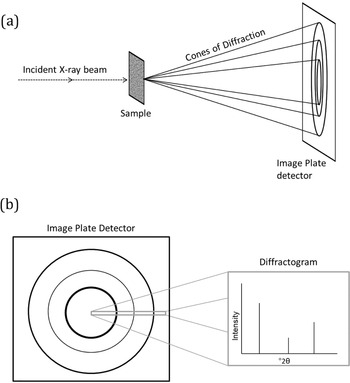

(image credit: https://www.cambridge.org/core/books/analytical-geomicrobiology/xray-diffraction-techniques/5527D02F25F05424B5974BD9E0FCB229)

Thus, a powder XRD pattern is an orientation-averaged fingerprint of the crystal: each peak corresponds to a particular interplanar spacing $d$, and therefore to a particular family of $(hkl)$ planes.

Earlier, we examined mirror planes in cubic lattices and computed their associated spacings using

$$
d_{hkl} = \frac{a}{\sqrt{h^2 + k^2 + l^2}},
$$

together with Bragg's law to predict peak positions. In a powder experiment, all such allowed planes contribute simultaneously, producing a one-dimensional spectrum of intensity versus $2\theta$.

You might therefore expect that every possible combination of $h$, $k$, and $l$ would generate a peak. However, real crystals possess additional symmetry. These symmetries impose selection rules that cause certain reflections to vanish identically. These missing peaks are called systematic absences (or characteristic absences), and they provide direct information about the underlying lattice type.

For common cubic lattices:
 - Simple cubic: Peaks appear for all integer combinations of $h$, $k$, and $l$.
 - Face-centered cubic (FCC): Peaks appear only when $h$, $k$, and $l$ are either all even or all odd.
 - Body-centered cubic (BCC): Peaks appear only when $h + k + l$ is even.

These rules arise from destructive interference between symmetry-related atoms within the unit cell. Physically, they reflect additional phase cancellations imposed by the lattice geometry.

By indexing the observed powder peaks with $(hkl)$ values and applying these selection rules, we can determine:

1. the lattice parameter $a$,
2. the crystal system (e.g., simple cubic, FCC, or BCC),
3. which reflections are allowed or forbidden by symmetry.

In other words, the powder XRD spectrum encodes both geometric information (interplanar spacings) and symmetry information (systematic absences).

### Coding Activity 5
`30 points`

- P2.2: Implement basic data-analysis workflows (peak identification and regression) using structured, reusable code
- P2.3: Construct small modular programs that separate physical models from visualization and analysis
- C2.2: Use powder XRD data to determine lattice spacings and relate extracted structural parameters to underlying crystal structures

#### Processing Powder XRD Spectra

In this section, you will analyze several powder XRD datasets and automate the interpretation process.

##### Setup

Ensure you have the following files in the same folder as this notebook:
 - `AuB2.xy`
 - `AgB2.xy`
 - `NbTa.xy`
 - `Po.xy`

Each file contains two columns: scattering angle ($2\theta$) and intensity.

##### Tasks
1. For $\ce{AgB2}$, use the provided starter code to:
        - load the spectrum
        - identify peak positions
        - assign candidate $(hkl)$ indices,
        - compute the lattice parameter $a$,
        - and determine the crystal type using the selection rules above.
   
    Add comments explaining the code.
2. Convert this workflow into a reusable function called `process_spectrum(filename)`

    Your function should:

    - accept a filename (string) as its only argument,
    - load and plot the XRD spectrum,
    - identify and index peaks,
    - compute and print:
        - the lattice parameter $a$,
        - the inferred crystal classification (simple cubic, FCC, or BCC),
    - return the `pandas.DataFrame` containing the picked peaks, computed $d$ values, and assigned $(hkl)$ indices.

    You may freely reuse and modify the $\ce{AgB2}$ analysis code.

3. Use your `process_spectrum()` function to analyze the remaining datasets:
     - `AuB2.xy`
     - `NbTa.xy`
     - `Po.xy`

    Compare the resulting lattice parameters and crystal classifications.

To support this analysis, we will use the `pandas.DataFrame` object. A `DataFrame` is similar to a spreadsheet: it organizes data into labeled columns and rows. You can load a file into a `DataFrame` using `pd.read_csv()`. Individual columns can be accessed using the subscript operator (square brackets), and new columns can be created in the same way.

In [ ]:
import pandas as pd
import numpy as np
from helper import plot_spectrum
from helper import pick_peaks
from helper import calculate_distances
from helper import index_hkl
from helper import classify_cubic_spectra

#AgB2
wavelength = 1.54 #1.54 angstrom wavelength x-rays used for all these
spectrum = pd.read_csv('data/AgB2.xy',sep=r'\s+',header=None,names=['2theta','intensity','_'])
spectrum #typing a variable by itself in the last line of a block will show its contents

,2theta,intensity,_
0,1.00,0.00000,0.0
1,1.01,0.44387,0.0
2,1.02,0.43533,0.0
3,1.03,0.42703,0.0
4,1.04,0.41898,0.0
...,...,...,...
11895,119.95,0.03020,0.0
11896,119.96,0.03003,0.0
11897,119.97,0.02987,0.0
11898,119.98,0.02970,0.0


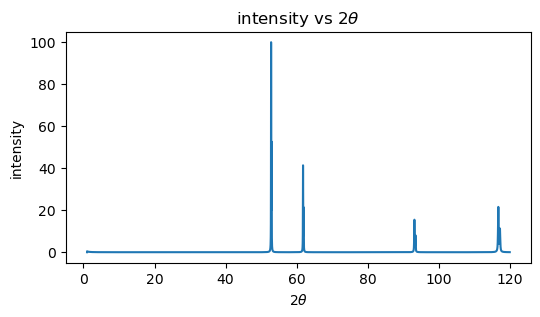

(<Figure size 600x300 with 1 Axes>,
 <Axes: title={'center': 'intensity vs $2\\theta$'}, xlabel='$2\\theta$', ylabel='intensity'>)

In [ ]:

plot_spectrum(spectrum['2theta'],spectrum['intensity'])

In [29]:
peaks = pick_peaks(spectrum['2theta'],spectrum['intensity'])
peaks

,2theta,intensity
0,52.81,100.00000
1,61.80,41.38197
2,93.14,15.48053
3,93.44,8.11418
4,116.77,21.58009


In [30]:
peaks['d'] = calculate_distances(peaks['2theta'],wavelength)
peaks

,2theta,intensity,d
0,52.81,100.00000,1.731452
1,61.80,41.38197,1.499393
2,93.14,15.48053,1.060292
3,93.44,8.11418,1.057675
4,116.77,21.58009,0.904191


In [31]:
peaks['hkl'], cell_param_a = index_hkl(peaks['d'],0)
peaks

,2theta,intensity,d,hkl
0,52.81,100.00000,1.731452,111
1,61.80,41.38197,1.499393,200
2,93.14,15.48053,1.060292,220
3,93.44,8.11418,1.057675,220
4,116.77,21.58009,0.904191,311


In [32]:
print(f'a: {cell_param_a:3f}')
classification = classify_cubic_spectra(peaks['hkl'])
print(f'Classification: {classification}')

a: 2.998964
Classification: face centered cubic


In [38]:
# Define a function called process_spectrum() which accepts one argument: a filename.
# Process the spectrum using the given functions in the same order as before.
# Print the cell parameter a and the classification.
# Return the DataFrame peaks containing peak data.
# you will need to genericize

def process_spectrum(filename):
    wavelength = 1.54 #1.54 angstrom wavelength x-rays used for all these
    spectrum = pd.read_csv(filename,sep=r'\s+',header=None,names=['2theta','intensity','_'])
    plot_spectrum(spectrum['2theta'],spectrum['intensity'])
    
    peaks = pick_peaks(spectrum['2theta'],spectrum['intensity'])
    peaks['d'] = calculate_distances(peaks['2theta'],wavelength)
    peaks['hkl'], cell_param_a = index_hkl(peaks['d'],0)
    classification = classify_cubic_spectra(peaks['hkl'])
    print(f'a: {cell_param_a:3f}')
    print(f'Classification: {classification}')
    return peaks

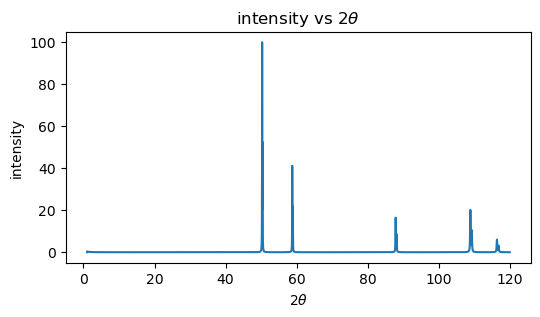

a: 3.138729
Classification: face centered cubic


,2theta,intensity,d,hkl
0,50.29,100.00000,1.812146,111
1,58.76,41.13951,1.569508,200
2,87.87,16.47745,1.109763,220
3,108.90,20.12055,0.946401,311
4,116.38,6.04808,0.906095,222
5,116.83,3.17449,0.903900,222


In [39]:
# AuB2.xy
process_spectrum("data/AuB2.xy")

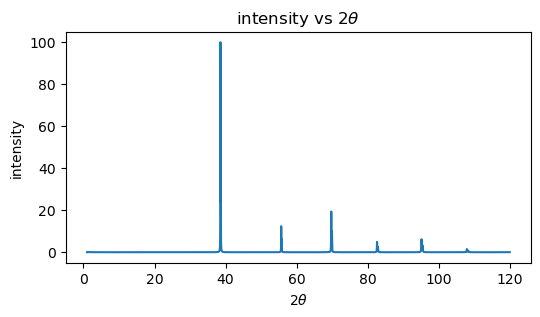

a: 2.332608
Classification: simple cubic


,2theta,intensity,d,hkl
0,38.55,100.00000,2.332608,100
1,55.66,12.37520,1.649353,110
2,55.81,6.38289,1.645275,110
3,69.75,19.35729,1.346653,111
4,82.63,4.92853,1.166316,200
5,95.15,6.17045,1.043133,210
6,95.45,3.22817,1.040646,210


In [40]:
# NbTa.xy
process_spectrum("data/NbTa.xy")

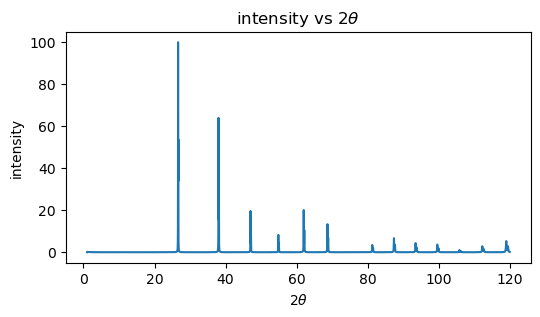

a: 3.343400
Classification: simple cubic


,2theta,intensity,d,hkl
0,26.63,100.00000,3.343400,100
1,38.01,63.97598,2.364497,110
2,47.01,19.63319,1.930652,111
3,54.85,8.24286,1.671779,200
4,54.99,4.33906,1.667854,200
5,61.99,20.05835,1.495252,210
6,68.68,13.33781,1.365000,211
7,68.87,6.93285,1.361697,211
8,81.29,3.45592,1.182123,220
9,87.39,6.69659,1.114619,221


In [41]:
# Po.xy
process_spectrum("data/Po.xy")

### Question 4
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.2: Use powder XRD data to determine lattice spacings and relate extracted structural parameters to underlying crystal structures

a) In a powder XRD experiment, why do diffraction peaks appear at fixed values of $2\theta$ even though the crystallites are randomly oriented? Explain your answer in terms of Bragg's law and geometric averaging.

b) For one dataset, list the first three observed $(hkl)$ reflections. Using these indices, explain how you determined whether the lattice is simple cubic, FCC, or BCC. Which reflections are systematically absent, and why?

c) Earlier in this lab, you derived diffraction conditions from phase matching between waves scattered by parallel planes. Explain how the appearance of discrete peaks in powder XRD is a direct consequence of this same phase-matching condition.

*Your answer here (`double click me!`):*


<br></br>

## Reflection
`10 points`

1. Throughout this lab, you encountered quantization in several different physical contexts: standing waves, slit diffraction, atomic planes, and powder XRD. In your own words, explain what these phenomena have in common. How does the requirement of phase matching lead to discrete allowed outcomes in each case?

2. In this experiment, crystal structure information emerged from interference between scattered X-ray waves, even though individual atoms were never directly observed. Reflect on how macroscopic measurements (diffraction peaks) encode microscopic order (lattice geometry). What assumptions about periodicity and coherence are essential for this connection to hold?

3. You used computational models to predict diffraction behavior and then compared those predictions to experimental data. How did writing and modifying your own code affect your understanding of XRD compared to treating it as a purely black-box technique? Give one specific example where computation clarified a physical concept.

*Your answer here (`double click me!`):*
